# Code along from June 8th w/ Dr. Karduni

## Setup

In [68]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import json

In [69]:
df_videos = pd.read_csv("youtube_videos.csv")
df_videos.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


## MinMax Scaler

Let's try scaling the subscriber count to min-max

In [70]:
scaler = MinMaxScaler()

In [71]:
df_videos["subscribers_minmax"] = scaler.fit_transform(df_videos[["subscribers"]])

In [72]:
df_videos["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

### Plot the subscriber count: as-is and compare against minmax

Text(0.5, 0, 'Raw subscribers')

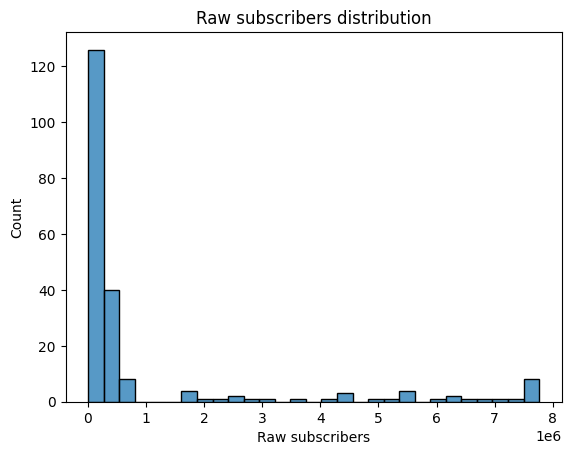

In [73]:
plt.figure()
sns.histplot(df_videos, x="subscribers")
plt.title("Raw subscribers distribution")
plt.xlabel("Raw subscribers")

Text(0.5, 0, 'Minmax Scaled subscribers')

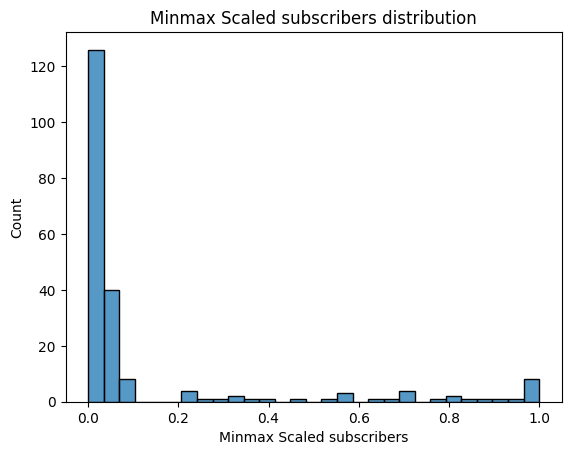

In [74]:
plt.figure()
sns.histplot(df_videos, x="subscribers_minmax")
plt.title("Minmax Scaled subscribers distribution")
plt.xlabel("Minmax Scaled subscribers")

## Standard scaler AKA z-score normalization

In [75]:
standard_scaler = StandardScaler()
df_videos["view_score"] = standard_scaler.fit_transform(df_videos[["views"]])
df_videos["view_score"].describe()

count    2.100000e+02
mean     2.537653e-17
std      1.002389e+00
min     -4.481625e-01
25%     -4.404694e-01
50%     -3.952794e-01
75%     -1.946757e-01
max      5.316044e+00
Name: view_score, dtype: float64

### Plotting views (raw and standard scaled)

Text(0.5, 0, 'Raw views')

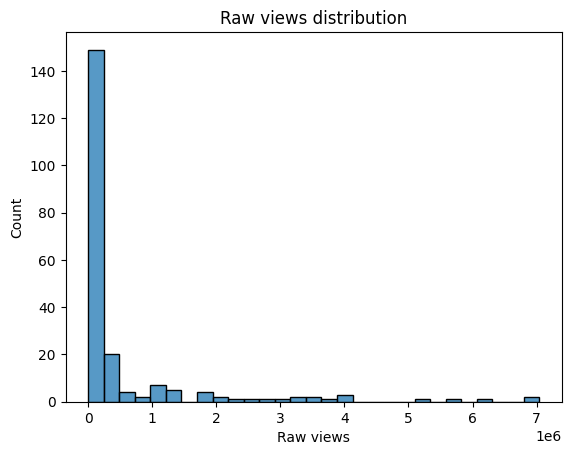

In [76]:
plt.figure()
sns.histplot(df_videos, x="views")
plt.title("Raw views distribution")
plt.xlabel("Raw views")

Text(0.5, 0, 'Min max scaled views')

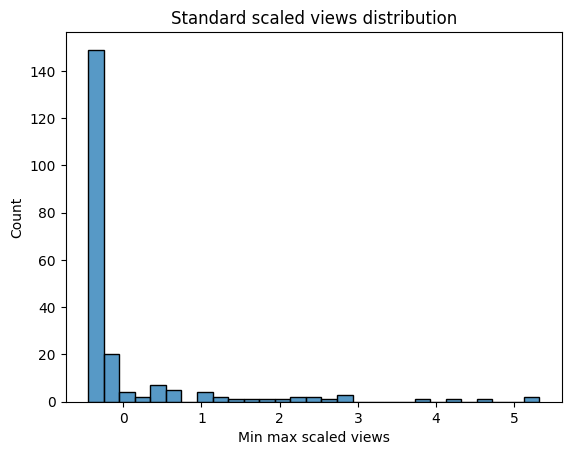

In [77]:
plt.figure()
df_videos["views_scaled"] = standard_scaler.fit_transform(df_videos[["views"]])
sns.histplot(df_videos, x="views_scaled")
plt.title("Standard scaled views distribution")
plt.xlabel("Min max scaled views")

## Robust Scaler

Text(0.5, 0, 'Shares after robust scaling')

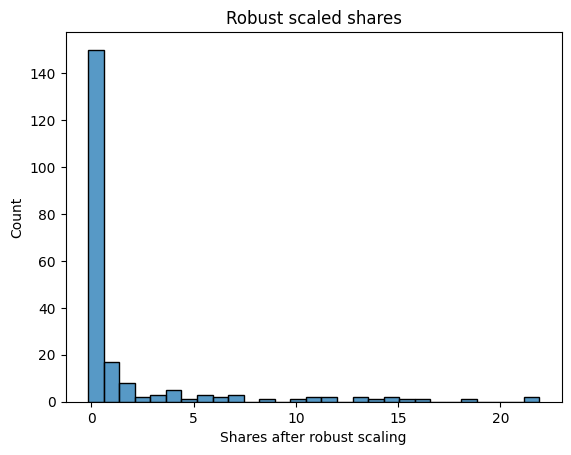

In [78]:
robust_scaler = RobustScaler()
df_videos["shares_scaled"] = robust_scaler.fit_transform(df_videos[["shares"]])
plt.figure()
sns.histplot(df_videos, x="shares_scaled")
plt.title("Robust scaled shares")
plt.xlabel("Shares after robust scaling")

Text(0.5, 0, 'Standard scaled shares')

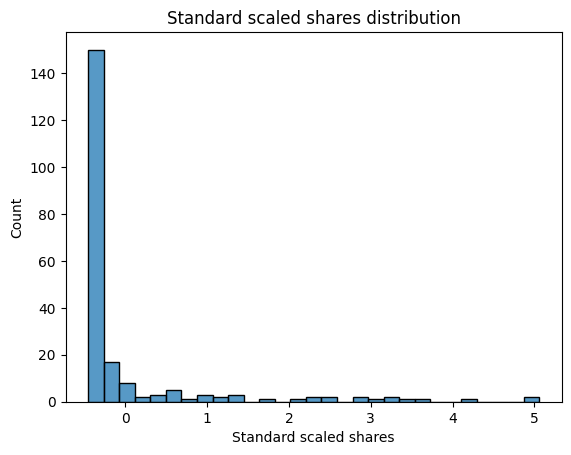

In [79]:
df_videos["shares_scaled_standard"] = standard_scaler.fit_transform(df_videos[["shares"]])
plt.figure()
sns.histplot(df_videos, x="shares_scaled_standard")
plt.title("Standard scaled shares distribution")
plt.xlabel("Standard scaled shares")

## Log scaling

Uses natural log and 1 + x to handle zeroes

Text(0.5, 0, 'Log likes')

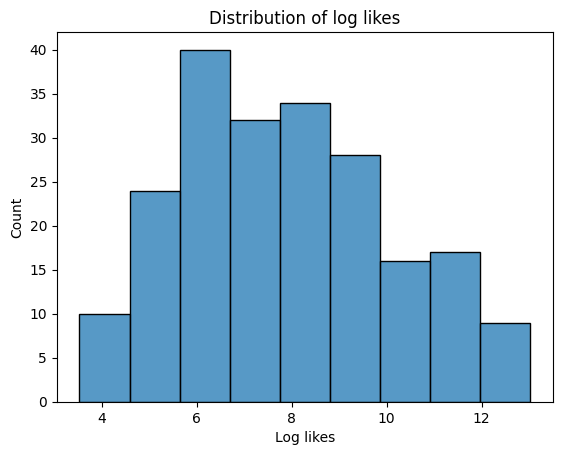

In [80]:
df_videos["likes_log"] = np.log1p(df_videos["likes"])
plt.figure()
sns.histplot(df_videos, x="likes_log")
plt.title("Distribution of log likes")
plt.xlabel("Log likes")

## Binning

Text(0.5, 0, 'Watch time classification')

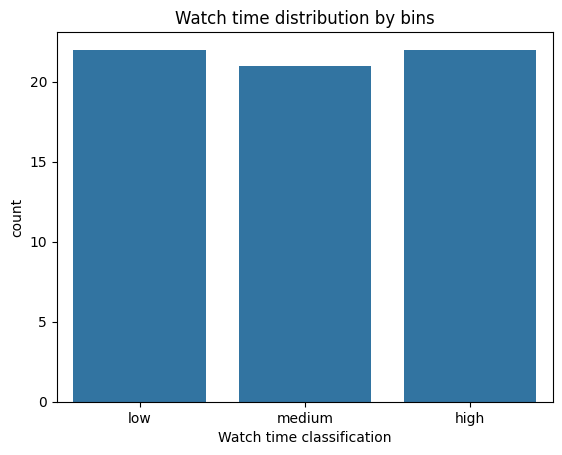

In [81]:
bins = [0, 50000, 100000, 200000]
labels = ["low", "medium", "high"]
df_videos["watch_time_minutes_bins"] = pd.cut(df_videos["watch_time_minutes"], bins=bins, labels=labels)
sns.countplot(df_videos, x="watch_time_minutes_bins")
plt.title("Watch time distribution by bins")
plt.xlabel("Watch time classification")

## Encoding categorical variables

### Ordinal encoding

In [82]:
enc = OrdinalEncoder(categories = [["Small", "Mid", "Large"]])
df_videos["channel_tier_encoded"] = enc.fit_transform(df_videos[["channel_tier"]])
display(df_videos)

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,tags_count,hashtags,subscribers_minmax,view_score,views_scaled,shares_scaled,shares_scaled_standard,likes_log,watch_time_minutes_bins,channel_tier_encoded
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,18.0,"[""ai"", ""tutorial"", ""trending""]",0.056122,-0.262478,-0.262478,0.393985,-0.316159,9.208338,NaN,1.0
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,17.0,"[""tutorial""]",0.002541,-0.428777,-0.428777,-0.069797,-0.432105,6.870053,NaN,0.0
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,NaN,"[""explained""]",0.308431,0.635144,0.635144,7.247848,1.397313,8.797851,NaN,2.0
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]",0.063485,-0.295529,-0.295529,0.671335,-0.246821,8.504513,NaN,1.0
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,10.0,"[""explained"", ""shorts""]",0.003147,-0.439012,-0.439012,-0.140053,-0.449669,6.656727,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,14.0,"[""ai""]",0.001006,-0.444043,-0.444043,-0.147400,-0.451506,4.997212,medium,0.0
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,0.0,"[""news"", ""chatgpt"", ""tech"", ""ai"", ""llm""]",0.000565,-0.445424,-0.445424,-0.121685,-0.445077,5.521461,high,0.0
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,9.0,"[""viral"", ""explained"", ""tech"", ""tutorial""]",0.061652,-0.363434,-0.363434,0.283779,-0.343711,6.826545,NaN,1.0
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,19.0,"[""tutorial"", ""shorts"", ""ai"", ""tech"", ""viral""]",0.000814,-0.446840,-0.446840,-0.140971,-0.449899,5.111988,medium,0.0


Text(0.5, 0, 'Channel tier (encoded)')

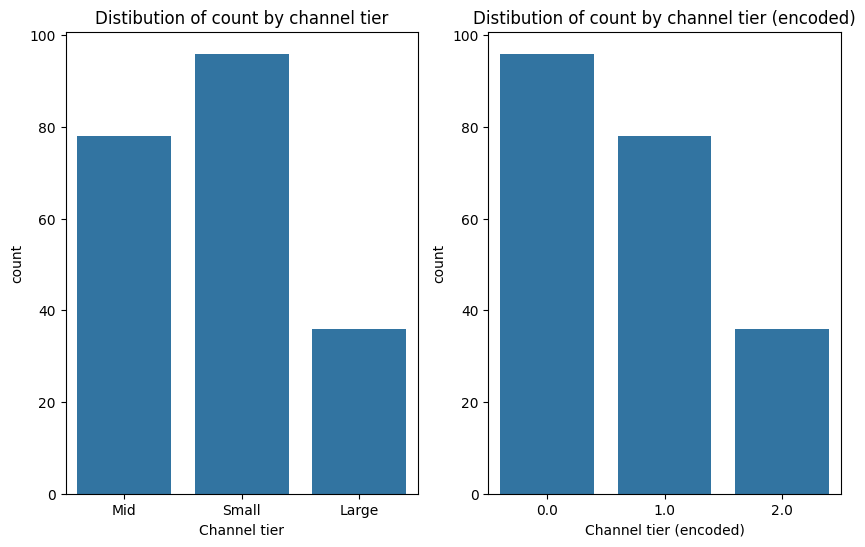

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))
order = ["Small", "Mid", "Large"]
sns.countplot(data=df_videos, x="channel_tier", ax=ax[0])
ax[0].set_title("Distibution of count by channel tier")
ax[0].set_xlabel("Channel tier")

sns.countplot(data=df_videos, x="channel_tier_encoded", ax=ax[1])
ax[1].set_title("Distibution of count by channel tier (encoded)")
ax[1].set_xlabel("Channel tier (encoded)")

### One hot encoding

In [84]:
dummyVars = pd.get_dummies(df_videos["category"], prefix="is")
display(dummyVars)
result = pd.concat([df_videos[["video_id", "category"]], dummyVars], axis=1)
display(result)

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


,video_id,category,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,Music,False,False,False,True,False,False
1,vid_0001,Gaming,False,False,True,False,False,False
2,vid_0002,Gaming,False,False,True,False,False,False
3,vid_0003,Gaming,False,False,True,False,False,False
4,vid_0004,Music,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
205,vid_0205,Education,False,True,False,False,False,False
206,vid_0206,News,False,False,False,False,True,False
207,vid_0207,Gaming,False,False,True,False,False,False
208,vid_0208,Comedy,True,False,False,False,False,False


## Date and time features

### Sample code

In [85]:
# simulate a full timestamp from existing day/hour columns
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df_videos["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df_videos["upload_day"], df_videos["upload_hour"])
]

display(df_videos["uploaded_at"])

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[us]

In [86]:
# extract features from timestamp
df_videos["is_weekend"] = (df_videos["uploaded_at"].dt.dayofweek >= 5).astype(int)
df_videos["is_primetime"] = (
    (df_videos["uploaded_at"].dt.hour >= 18) &
    (df_videos["uploaded_at"].dt.hour <= 22)
).astype(int)
display(df_videos)

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,view_score,views_scaled,shares_scaled,shares_scaled_standard,likes_log,watch_time_minutes_bins,channel_tier_encoded,uploaded_at,is_weekend,is_primetime
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,-0.262478,-0.262478,0.393985,-0.316159,9.208338,NaN,1.0,2024-01-07 00:05:00,1,0
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,-0.428777,-0.428777,-0.069797,-0.432105,6.870053,NaN,0.0,2024-01-06 21:46:00,1,1
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,0.635144,0.635144,7.247848,1.397313,8.797851,NaN,2.0,2024-01-08 18:39:00,0,1
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,-0.295529,-0.295529,0.671335,-0.246821,8.504513,NaN,1.0,2024-01-04 14:26:00,0,0
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,-0.439012,-0.439012,-0.140053,-0.449669,6.656727,NaN,0.0,2024-01-08 04:25:00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,-0.444043,-0.444043,-0.147400,-0.451506,4.997212,medium,0.0,2024-01-05 13:15:00,0,0
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,-0.445424,-0.445424,-0.121685,-0.445077,5.521461,high,0.0,2024-01-06 08:45:00,1,0
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,-0.363434,-0.363434,0.283779,-0.343711,6.826545,NaN,1.0,2024-01-07 20:58:00,1,1
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,-0.446840,-0.446840,-0.140971,-0.449899,5.111988,medium,0.0,2024-01-04 21:15:00,0,1


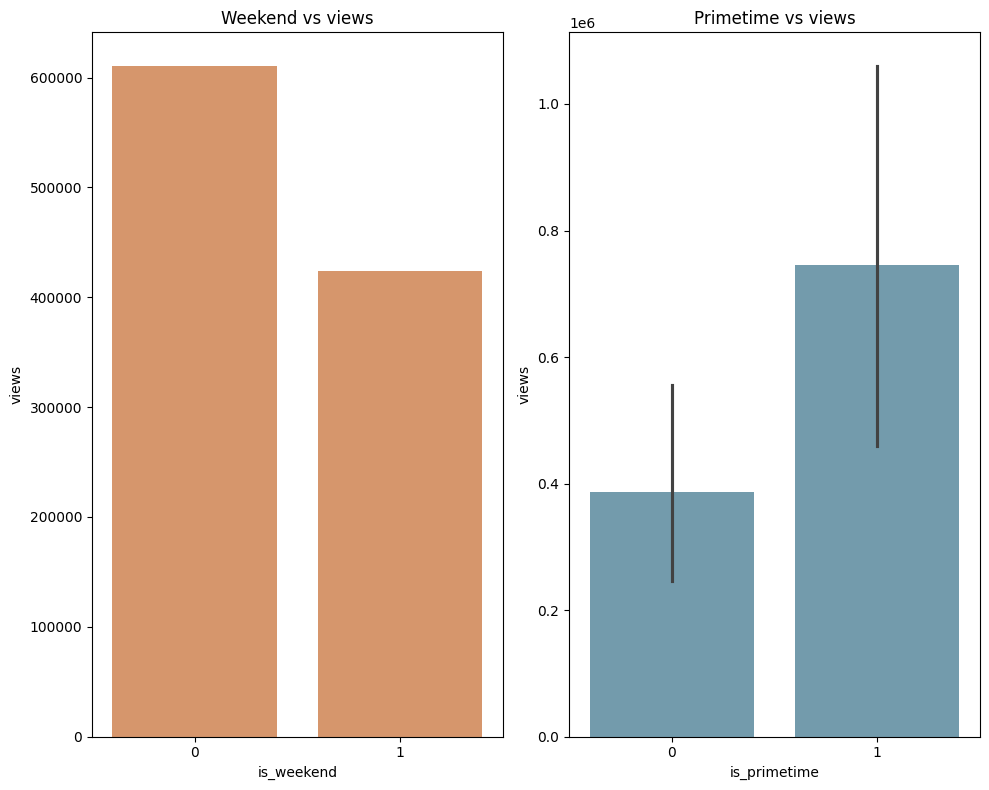

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

sns.barplot(data=df_videos,
            x="is_weekend",
            y="views",
            color="#e8925a",
            errorbar=None,
            ax=axes[0])
axes[0].set_title("Weekend vs views")
axes[0].set_xlabel("is_weekend")

sns.barplot(data=df_videos,
            x="is_primetime",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("Primetime vs views")
axes[1].set_xlabel("is_primetime")

plt.tight_layout()
plt.show()

## Counting caps

In [88]:
df_videos["num_uppercase"] = df_videos["title"].apply(lambda t: sum(1 for w in t.split() if w.isupper()))
display(df_videos)

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,views_scaled,shares_scaled,shares_scaled_standard,likes_log,watch_time_minutes_bins,channel_tier_encoded,uploaded_at,is_weekend,is_primetime,num_uppercase
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,-0.262478,0.393985,-0.316159,9.208338,NaN,1.0,2024-01-07 00:05:00,1,0,3
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,-0.428777,-0.069797,-0.432105,6.870053,NaN,0.0,2024-01-06 21:46:00,1,1,1
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,0.635144,7.247848,1.397313,8.797851,NaN,2.0,2024-01-08 18:39:00,0,1,0
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,-0.295529,0.671335,-0.246821,8.504513,NaN,1.0,2024-01-04 14:26:00,0,0,0
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,-0.439012,-0.140053,-0.449669,6.656727,NaN,0.0,2024-01-08 04:25:00,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,-0.444043,-0.147400,-0.451506,4.997212,medium,0.0,2024-01-05 13:15:00,0,0,3
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,-0.445424,-0.121685,-0.445077,5.521461,high,0.0,2024-01-06 08:45:00,1,0,2
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,-0.363434,0.283779,-0.343711,6.826545,NaN,1.0,2024-01-07 20:58:00,1,1,0
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,-0.446840,-0.140971,-0.449899,5.111988,medium,0.0,2024-01-04 21:15:00,0,1,2


Text(0, 0.5, 'views')

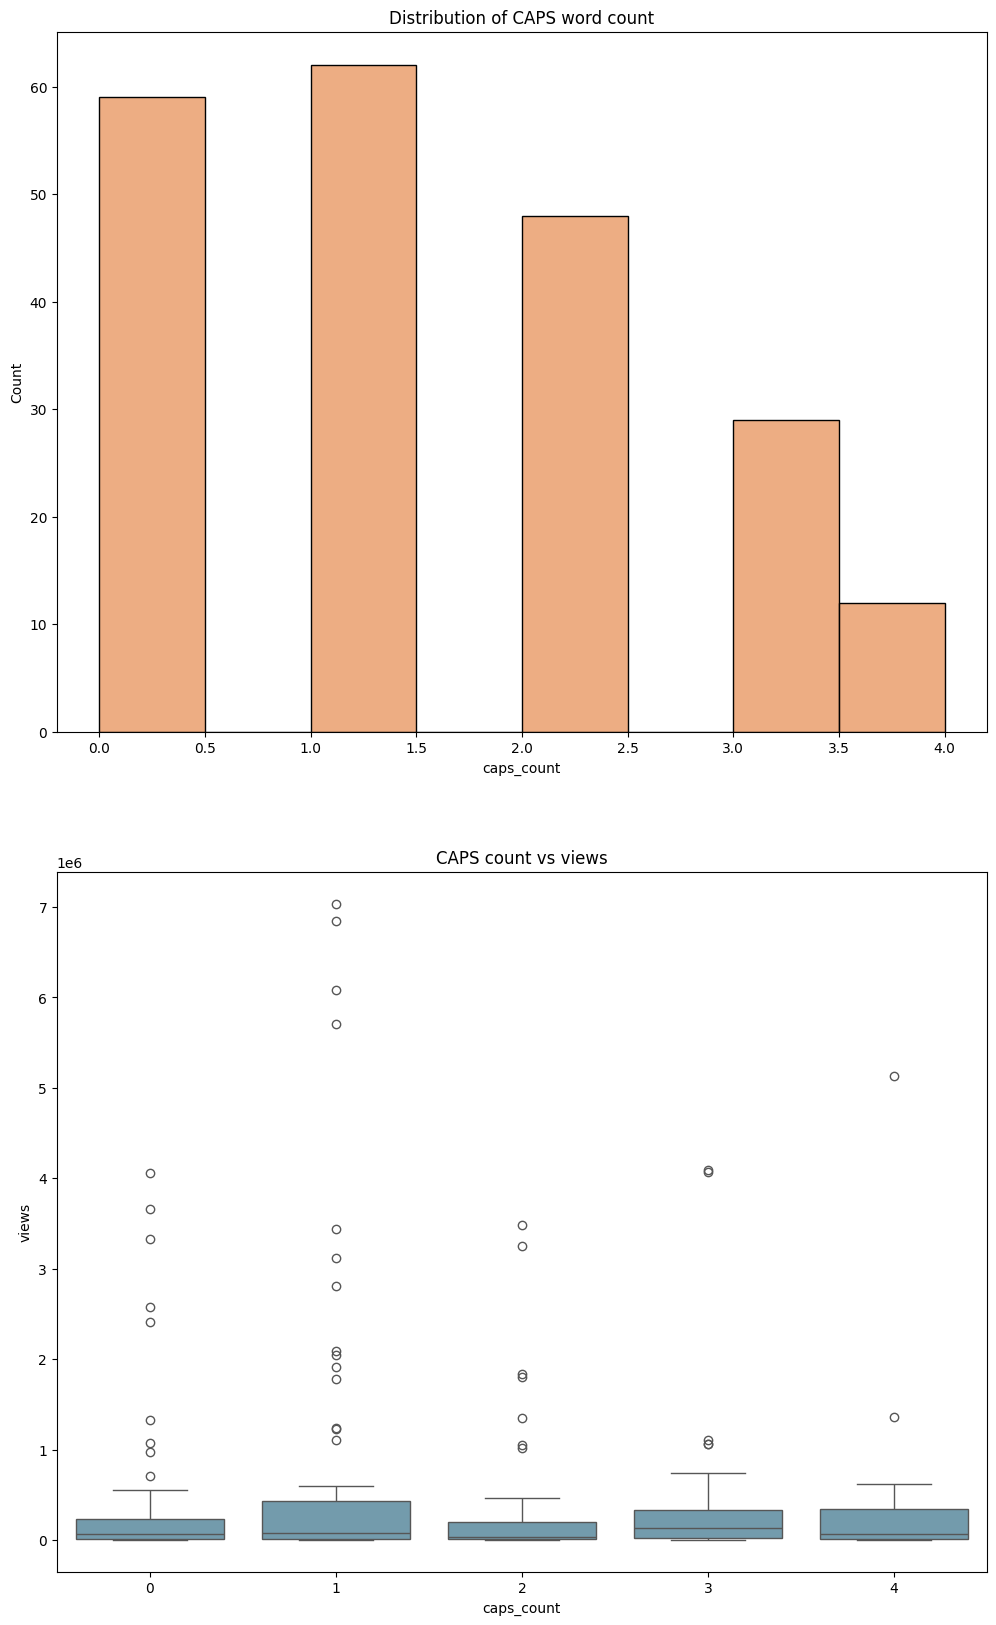

In [89]:
fig, axes = plt.subplots(2, 1, figsize=(12, 20))
sns.histplot(df_videos["num_uppercase"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df_videos,
            x="num_uppercase",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

## TF-IDF

In [90]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df_videos["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df_videos = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

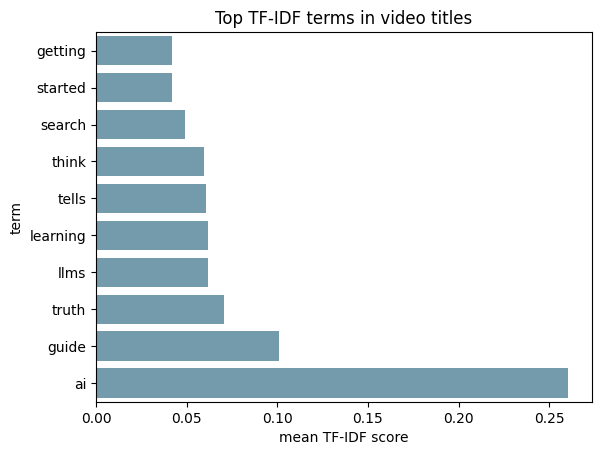

In [91]:
sns.barplot(data=tfidf_df_videos,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.show()

## Retention rate

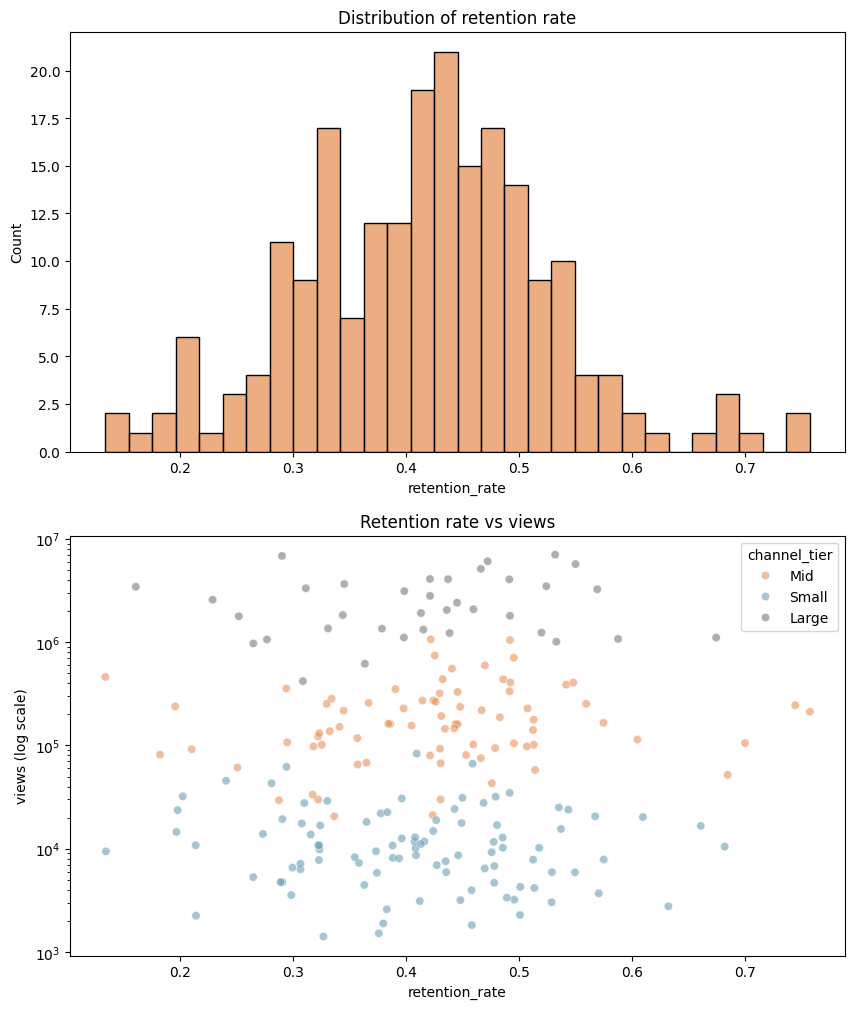

In [92]:
df_videos["duration_minutes"] = df_videos["duration_seconds"] / 60

df_videos["retention_rate"] = (
    df_videos["watch_time_minutes"] /
    (df_videos["views"] * df_videos["duration_minutes"])
).clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

sns.histplot(df_videos["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df_videos,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

plt.show()

## Interaction features

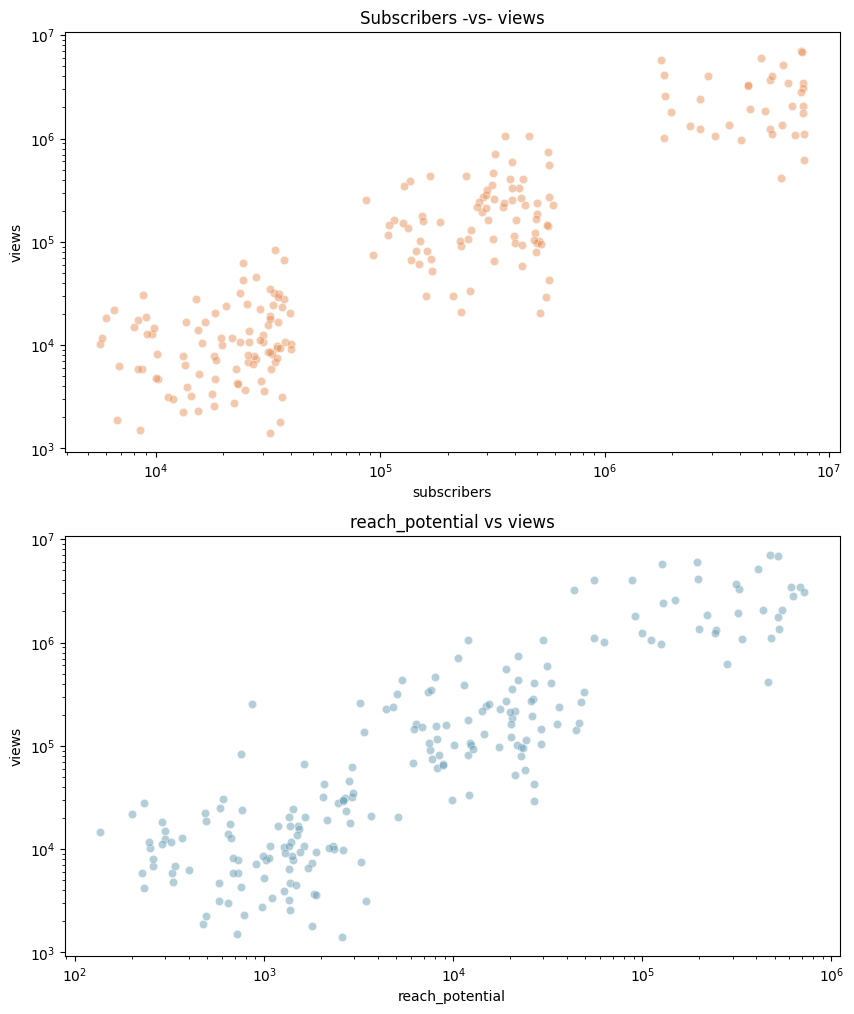

In [93]:
df_videos["reach_potential"] = (
    df_videos["subscribers"] * df_videos["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

sns.scatterplot(data=df_videos,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Subscribers -vs- views")

sns.scatterplot(data=df_videos,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

plt.show()

## Multi encoding

In [94]:
mlb = MultiLabelBinarizer()
df_videos["hashtags"] = df_videos["hashtags"].apply(json.loads)
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df_videos["hashtags"]),
    columns=mlb.classes_,
    index=df_videos.index
)
df_videos = pd.concat(
    [df_videos, hashtag_encoded],
    axis=1
)

### For fun: correlation matrix of hashtag with view count (min-max)

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,news,python,review,shorts,tech,trending,tutorial,viral,vlog,views_minmax
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,0,0,0,0,0,1,1,0,0,0.032213
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,0,0,0,0,0,0,1,0,0,0.003363
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,0,0,0,0,0,0,0,0,0,0.187937
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,0,0,0,0,1,1,0,0,0,0.026480
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,0,0,0,1,0,0,0,0,0,0.001587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,0,0,0,0,0,0,0,0,0,0.000715
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,1,0,0,0,1,0,0,0,0,0.000475
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,0,0,0,0,1,0,1,1,0,0.014699
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,0,0,0,1,1,0,1,1,0,0.000229


,views_minmax,vlog,viral,tutorial,trending,tech,shorts,review,python,news,...,machinelearning,llm,howto,gaming,explained,deeplearning,datascience,comedy,chatgpt,ai
views_minmax,1.000000,-0.059685,0.093046,-7.772562e-02,-0.011927,0.005767,-0.032449,0.008210,9.853688e-03,-0.061303,...,-0.051926,-0.092599,1.520279e-02,-0.054830,-0.007845,-0.011335,-0.028896,-0.030129,-0.077477,0.001983
vlog,-0.059685,1.000000,-0.068642,8.834522e-02,-0.078087,-0.104564,0.152966,0.030565,-3.304694e-02,-0.044850,...,-0.033047,-0.058706,2.306839e-01,-0.043315,0.086464,-0.033047,-0.031080,-0.036718,-0.046350,0.012381
viral,0.093046,-0.068642,1.000000,1.005500e-01,0.168053,-0.042610,0.033256,-0.042610,-2.917804e-02,-0.126224,...,-0.093005,-0.165219,-1.082035e-01,0.129073,-0.013533,-0.093005,-0.019938,0.012710,-0.130445,0.045603
tutorial,-0.077726,0.088345,0.100550,1.000000e+00,-0.025254,-0.101970,-0.083444,-0.014567,5.191209e-19,-0.012692,...,-0.099751,0.010223,2.717789e-18,0.039223,-0.056943,0.049875,-0.035180,-0.075567,-0.024689,-0.007007
trending,-0.011927,-0.078087,0.168053,-2.525381e-02,1.000000,0.025751,-0.135708,-0.051503,-1.058018e-01,0.125643,...,-0.105802,-0.007229,-1.230915e-01,0.184900,-0.055364,-0.105802,-0.099504,-0.117555,-0.061103,-0.004955
tech,0.005767,-0.104564,-0.042610,-1.019700e-01,0.025751,1.000000,-0.007901,-0.047215,-3.995986e-02,0.118326,...,0.010898,-0.001489,1.267907e-02,0.054280,0.087615,-0.090818,0.081995,0.027520,0.027873,0.053077
shorts,-0.032449,0.152966,0.033256,-8.344351e-02,-0.135708,-0.007901,1.000000,0.017625,-1.073740e-01,-0.145725,...,-0.107374,-0.190745,2.759873e-02,-0.140736,0.111304,-0.107374,-0.100982,0.198499,-0.150599,0.108984
review,0.008210,0.030565,-0.042610,-1.456714e-02,-0.051503,-0.047215,0.017625,1.000000,-9.081787e-02,0.001849,...,-0.039960,0.092333,1.014325e-01,0.054280,0.000518,-0.039960,-0.133242,0.027520,-0.009891,0.053077
python,0.009854,-0.033047,-0.029178,5.191209e-19,-0.105802,-0.039960,-0.107374,-0.090818,1.000000e+00,-0.060769,...,0.071310,-0.008158,-5.209323e-02,-0.058688,-0.101532,0.187396,0.203535,-0.049750,0.023397,0.134197
news,-0.061303,-0.044850,-0.126224,-1.269183e-02,0.125643,0.118326,-0.145725,0.001849,-6.076904e-02,1.000000,...,-0.060769,0.273517,-7.069963e-02,-0.079650,-0.129365,-0.060769,-0.057152,-0.067519,0.243790,0.007826


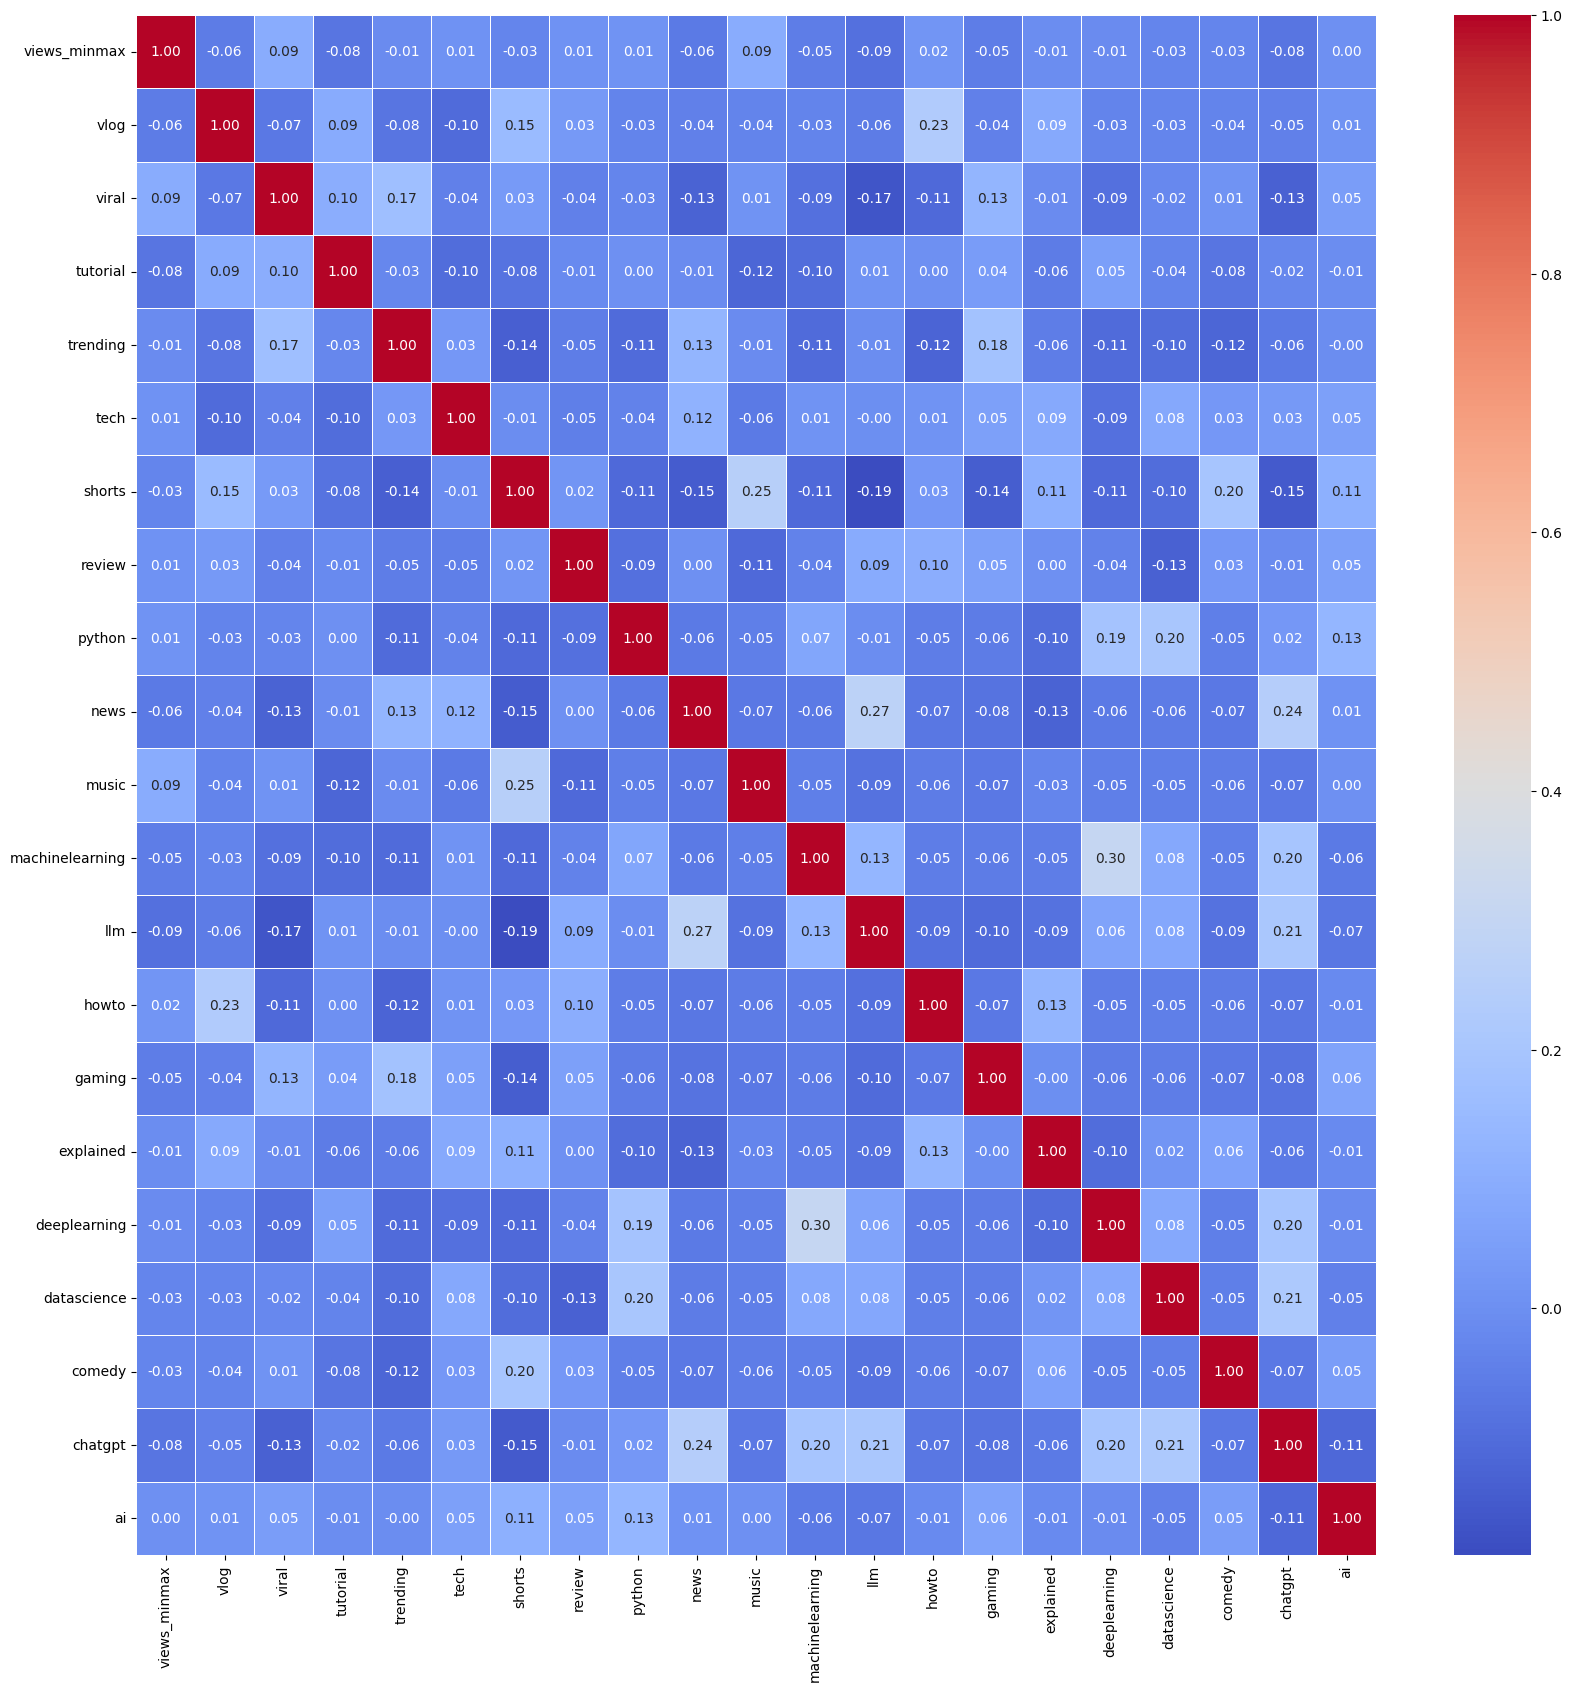

In [99]:
df_videos["views_minmax"] = scaler.fit_transform(df_videos[["views"]])
display(df_videos)
correlation_columns = ["views_minmax", "vlog", "viral", "tutorial", "trending", "tech", "shorts", "review", "python", "news", "music", "machinelearning", "llm", "howto", "gaming", "explained", "deeplearning", "datascience", "comedy", "chatgpt", "ai" ]
correlation_matrix = df_videos[correlation_columns].corr()
display (correlation_matrix)
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()